# 🌍 Project 1: Global Immunization Coverage Analysis
**Data Source:** WHO/UNICEF WUENIC 2024  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Analyst:** Oluwapelumi Abigael Oyesanya  
**Objective:** Analyse global vaccination coverage trends across countries, regions and selected vaccine types from 1980 to 2024 — identifying where the biggest gaps exist and which populations remain most at risk.

In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================
# pandas     — loading, cleaning and manipulating tabular data
# numpy      — numerical operations
# matplotlib — building and saving professional charts
# seaborn    — statistical visualizations
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size']      = 12

print('Libraries loaded successfully')

Libraries loaded successfully


In [8]:
# ============================================================
# CELL 2: DATA QUALITY AUDIT — ALL 16 VACCINE SHEETS
# ============================================================
# Before loading any data for analysis, we audit ALL sheets
# in the WUENIC file to understand their completeness.
#
# This step is non-negotiable in professional analytics:
# using data with high missing values without documenting it
# produces misleading results and undermines credibility.
#
# The audit output drives our sheet selection decisions
# in the next cell — every inclusion and exclusion is
# justified by the numbers here, not arbitrary choice.
# ============================================================

# ============================================================
# CELL 2: DATA QUALITY AUDIT — ALL VACCINE SHEETS
# ============================================================

file_path = r'C:\Users\USER\Documents\WORK PROJECT\wuenic2024rev_web-update.xlsx'
year_columns = [str(y) for y in range(1980, 2025)]

# Open the multi-sheet workbook
xl = pd.ExcelFile(file_path)

# Keep only sheets with the expected vaccine-data structure
required_columns = {'unicef_region', 'iso3', 'country', 'vaccine'}

all_vaccine_sheets = []

for sheet in xl.sheet_names:
    df = xl.parse(sheet)

    if required_columns.issubset(df.columns):
        all_vaccine_sheets.append(sheet)

# Audit data quality for every vaccine sheet
audit_results = {}

for sheet in all_vaccine_sheets:
    df = xl.parse(sheet)

    df_long = df.melt(
        id_vars=['unicef_region', 'iso3', 'country', 'vaccine'],
        value_vars=year_columns,
        var_name='year',
        value_name='coverage'
    )

    df_long['coverage'] = pd.to_numeric(
        df_long['coverage'],
        errors='coerce'
    )

    missing_pct = df_long['coverage'].isna().mean() * 100
    retained = df_long['coverage'].notna().sum()

    audit_results[sheet] = {
        'Missing %': round(missing_pct, 1),
        'Rows Retained': retained
    }

audit_df = pd.DataFrame(audit_results).T.sort_values('Missing %')

print('DATA QUALITY AUDIT — ALL VACCINE SHEETS')
print('=' * 50)
print(audit_df.to_string())
print('\nThis audit supports the sheet-selection decisions below.')

DATA QUALITY AUDIT — ALL VACCINE SHEETS
       Missing %  Rows Retained
DTP1         7.2         8100.0
DTP3         7.2         8100.0
POL3         7.2         8105.0
MCV1         8.7         7974.0
BCG         12.0         6613.0
RCV1        44.6         4410.0
HEPB3       44.7         4727.0
YFV         51.0          838.0
HIB3        54.4         3961.0
MCV2        59.8         3436.0
HEPBB       62.8         1876.0
PCV3        74.0         1860.0
ROTAC       77.6         1278.0
IPV1        79.1         1823.0
MENGA       86.1           94.0
IPV2        93.0          314.0

This audit supports the sheet-selection decisions below.


In [12]:
# ============================================================
# CELL 3: SHEET SELECTION — WITH DOCUMENTED REASONING
# ============================================================
# Based on the audit above, we classify sheets into three
# groups and document the reason for every decision.
#
# INCLUDED — Full analysis (under 15% missing):
#   DTP1   7.2% — measures first contact with health system
#   DTP3   7.2% — WHO/UNICEF primary global benchmark
#   POL3   7.2% — polio eradication story
#   MCV1   8.7% — measles elimination tracking
#   BCG   12.0% — TB vaccine, oldest global immunization program
#
# INCLUDED — With documented caution (15-65% missing):
#   HEPB3 44.7% — WHO priority vaccine, high global burden
#   MCV2  59.8% — WHO priority, tracks measles second dose gap
#
# EXCLUDED — Reasoning documented:
#   HEPBB  62.8% — birth dose variant, limited reporting
#   HIB3   54.4% — redundant with HEPB3, high missing
#   RCV1   44.6% — lower global priority vs others
#   YFV    51.0% — region-specific (West Africa only)
#   IPV1   79.1% — insufficient data
#   IPV2   93.0% — insufficient data
#   MENGA  86.1% — insufficient data
#   PCV3   74.0% — insufficient data
#   ROTAC  77.6% — insufficient data
# ============================================================

selected_full    = ['BCG', 'DTP1', 'DTP3', 'MCV1', 'POL3']
selected_caution = ['HEPB3', 'MCV2']

region_labels = {
    'EAPR': 'East Asia & Pacific',
    'ECAR': 'Europe & Central Asia',
    'ESAR': 'Eastern & Southern Africa',
    'LACR': 'Latin America & Caribbean',
    'MENA': 'Middle East & North Africa',
    'ROSA': 'South Asia',
    'WCAR': 'West & Central Africa'
}
# Combine the selected vaccine sheets
selected_sheets = selected_full + selected_caution

# Identify the remaining vaccine sheets that were not selected
excluded_sheets = [
    sheet for sheet in all_vaccine_sheets
    if sheet not in selected_sheets
]

print('Sheet selection complete')
print(f'Full analysis    : {selected_full}')
print(f'Caution included : {selected_caution}')
print(f'Excluded          : {len(excluded_sheets)} sheets')

Sheet selection complete
Full analysis    : ['BCG', 'DTP1', 'DTP3', 'MCV1', 'POL3']
Caution included : ['HEPB3', 'MCV2']
Excluded          : 9 sheets


In [13]:
# ============================================================
# CELL 4: LOAD AND CLEAN REGIONAL SHEET
# ============================================================
# The regional_global sheet contains aggregated coverage data
# by UNICEF region — it is the foundation for most of our
# regional and global level visualizations.
#
# Issue: vaccinated/unvaccinated/target columns contain commas
# (e.g. '18,286,000') which Python reads as strings, not numbers.
# We strip commas and convert to numeric before any calculation.
# ============================================================

df_regional = pd.read_excel(
    file_path,
    sheet_name='regional_global'
)

# Convert relevant population columns from text to numeric
for col in ['vaccinated', 'unvaccinated']:
    df_regional[col] = pd.to_numeric(
        df_regional[col].astype(str).str.replace(',', ''),
        errors='coerce'
    )

before = len(df_regional)

df_regional = df_regional.dropna(
    subset=['vaccinated']
)

after = len(df_regional)
rows_dropped = before - after
missing_pct = rows_dropped / before * 100

print('Regional sheet loaded and cleaned')
print(f'Rows before cleaning : {before:,}')
print(f'Rows dropped         : {rows_dropped:,} ({missing_pct:.1f}%)')
print(f'Rows retained        : {after:,}')
print(f'Year range           : {df_regional["year"].min()} to {df_regional["year"].max()}')
print(f'Unique regions       : {df_regional["region"].nunique()}')
print(f'Unique vaccines      : {df_regional["vaccine"].nunique()}')

Regional sheet loaded and cleaned
Rows before cleaning : 4,181
Rows dropped         : 285 (6.8%)
Rows retained        : 3,896
Year range           : 1980 to 2024
Unique regions       : 9
Unique vaccines      : 16


In [14]:
# ============================================================
# CELL 5: RESHAPE AND CLEAN VACCINE SHEETS
# ============================================================
# Vaccine sheets arrive in WIDE FORMAT:
#   Each year (1980 to 2024) is a separate column
#
# We convert to LONG FORMAT using pd.melt():
#   One row per country per year
#   e.g. country | year | coverage
#        Nigeria | 2020 | 65
# ============================================================

def reshape_and_clean(sheet_name):
    df = xl.parse(sheet_name)
    df_long = df.melt(
        id_vars=['unicef_region', 'iso3', 'country', 'vaccine'],
        value_vars=year_columns,
        var_name='year',
        value_name='coverage'
    )
    df_long['year']     = df_long['year'].astype(int)
    df_long['coverage'] = pd.to_numeric(df_long['coverage'], errors='coerce')
    before  = len(df_long)
    df_long = df_long.dropna(subset=['coverage'])
    after   = len(df_long)
    pct     = round((before - after) / before * 100, 1)
    print(f'{sheet_name:<8}: {pct}% dropped — {after:,} rows retained')
    return df_long

print('FULL RELIABILITY SHEETS (under 15% missing):')
full_dfs = {v: reshape_and_clean(v) for v in selected_full}

print('\nINCLUDED WITH CAUTION (WHO priority vaccines):')
caution_dfs = {v: reshape_and_clean(v) for v in selected_caution}

print('\nAll selected sheets loaded and reshaped successfully')

FULL RELIABILITY SHEETS (under 15% missing):
BCG     : 12.0% dropped — 6,613 rows retained
DTP1    : 7.2% dropped — 8,100 rows retained
DTP3    : 7.2% dropped — 8,100 rows retained
MCV1    : 8.7% dropped — 7,974 rows retained
POL3    : 7.2% dropped — 8,105 rows retained

INCLUDED WITH CAUTION (WHO priority vaccines):
HEPB3   : 44.7% dropped — 4,727 rows retained
MCV2    : 59.8% dropped — 3,436 rows retained

All selected sheets loaded and reshaped successfully


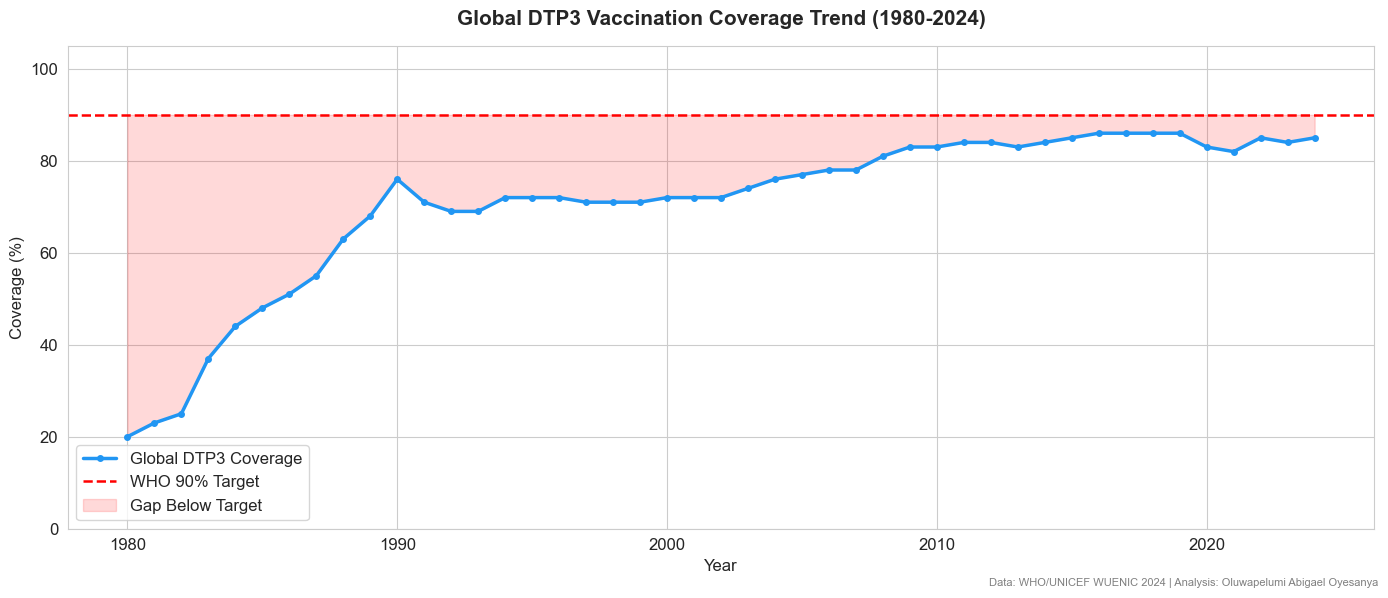

Chart 1 saved


In [16]:
# ============================================================
# CELL 6: CHART 1 — GLOBAL DTP3 TREND (1980-2024)
# ============================================================
# DTP3 is WHO and UNICEF's primary benchmark for measuring
# whether children are fully immunized globally.
#
# Key events visible in this trend:
#   1980s-1990s: Sharp coverage rise globally
#   2000s: Coverage plateaus — hardest-to-reach children remain
#   2019-2021: Post-COVID dip from pandemic disruptions
# ============================================================

df_global_dtp3 = df_regional[
    (df_regional['vaccine'] == 'DTP3') &
    (df_regional['region']  == 'Global')
].sort_values('year')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_global_dtp3['year'], df_global_dtp3['coverage'],
        color='#2196F3', linewidth=2.5, marker='o', markersize=4,
        label='Global DTP3 Coverage')
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.8, label='WHO 90% Target')
ax.fill_between(df_global_dtp3['year'], df_global_dtp3['coverage'], 90,
                where=(df_global_dtp3['coverage'] < 90),
                alpha=0.15, color='red', label='Gap Below Target')
ax.set_title('Global DTP3 Vaccination Coverage Trend (1980-2024)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year'); ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 105); ax.legend()
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()

import os
os.makedirs('charts', exist_ok=True)

plt.savefig(
    'charts/chart1_global_dtp3_trend.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print('Chart 1 saved')

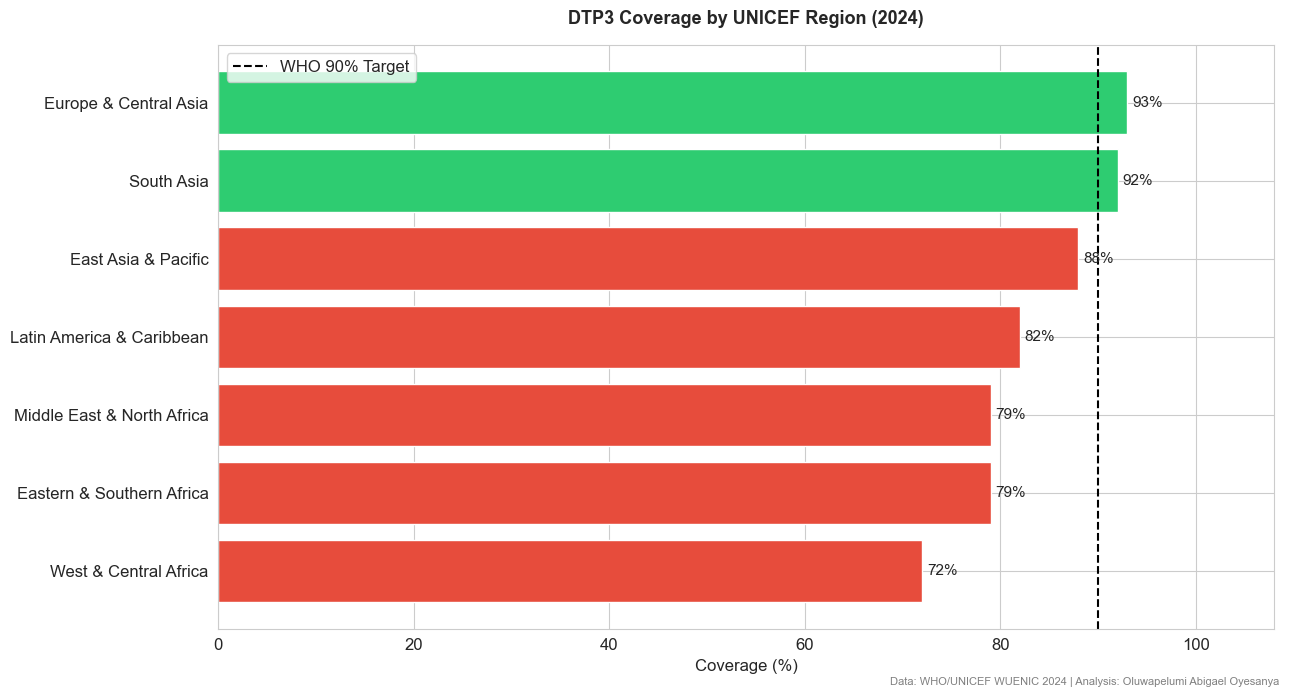

Chart 2 saved


In [17]:
# ============================================================
# CELL 7: CHART 2 — REGIONAL DTP3 COMPARISON (2024)
# ============================================================
# Compares today's DTP3 coverage across all 7 UNICEF regions.
# Color coding makes the WHO target gap immediately visible:
#   Green — meeting the WHO 90% target
#   Red   — still below the WHO 90% target
# ============================================================

df_reg_2024 = df_regional[
    (df_regional['vaccine'] == 'DTP3') &
    (df_regional['year']    == 2024) &
    (~df_regional['region'].isin(['Global', 'Non-programme']))
].copy()
df_reg_2024['region_label'] = df_reg_2024['region'].map(region_labels).fillna(df_reg_2024['region'])
df_reg_2024 = df_reg_2024.sort_values('coverage', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#e74c3c' if x < 90 else '#2ecc71' for x in df_reg_2024['coverage']]
bars   = ax.barh(df_reg_2024['region_label'], df_reg_2024['coverage'], color=colors)
ax.axvline(x=90, color='black', linestyle='--', linewidth=1.5, label='WHO 90% Target')
for bar, val in zip(bars, df_reg_2024['coverage']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=11)
ax.set_title('DTP3 Coverage by UNICEF Region (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Coverage (%)'); ax.set_xlim(0, 108); ax.legend()
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart2_regional_dtp3_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved')

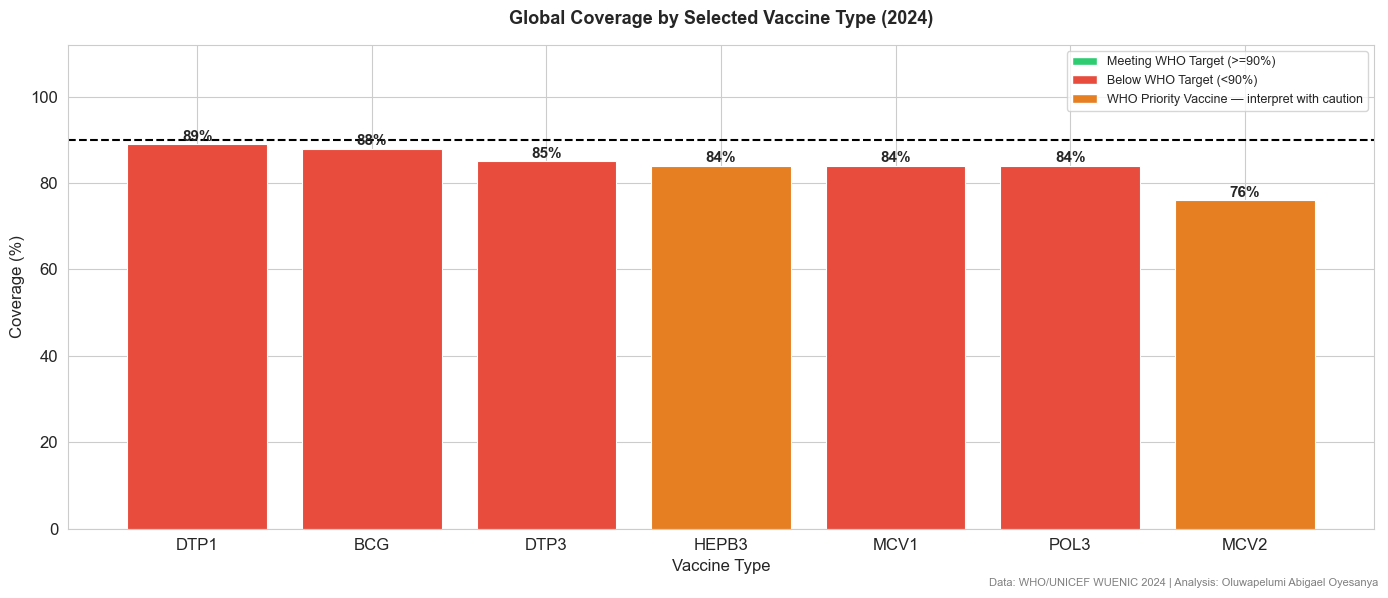

Chart 3 saved


In [18]:
# ============================================================
# CELL 8: CHART 3 — ALL SELECTED VACCINES COMPARISON (2024)
# ============================================================
# Compares all 7 selected vaccines globally in one chart.
# Three-color system flags data reliability:
#   Green  — core vaccine meeting WHO target (reliable data)
#   Red    — core vaccine below WHO target (reliable data)
#   Orange — WHO priority vaccine with high missing data
#             (interpret directionally, not as precise figures)
# ============================================================

all_selected = selected_full + selected_caution
df_vax_2024  = df_regional[
    (df_regional['year']    == 2024) &
    (df_regional['region']  == 'Global') &
    (df_regional['vaccine'].isin(all_selected))
].sort_values('coverage', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = []
for _, row in df_vax_2024.iterrows():
    if row['vaccine'] in selected_caution:
        colors.append('#e67e22')
    elif row['coverage'] >= 90:
        colors.append('#2ecc71')
    else:
        colors.append('#e74c3c')

bars = ax.bar(df_vax_2024['vaccine'], df_vax_2024['coverage'],
              color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(y=90, color='black', linestyle='--', linewidth=1.5, label='WHO 90% Target')
for bar, val in zip(bars, df_vax_2024['coverage']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val:.0f}%', ha='center', fontsize=11, fontweight='bold')

legend_elements = [
    Patch(facecolor='#2ecc71', label='Meeting WHO Target (>=90%)'),
    Patch(facecolor='#e74c3c', label='Below WHO Target (<90%)'),
    Patch(facecolor='#e67e22', label='WHO Priority Vaccine — interpret with caution')
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title('Global Coverage by Selected Vaccine Type (2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Vaccine Type'); ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 112)
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart3_vaccine_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved')

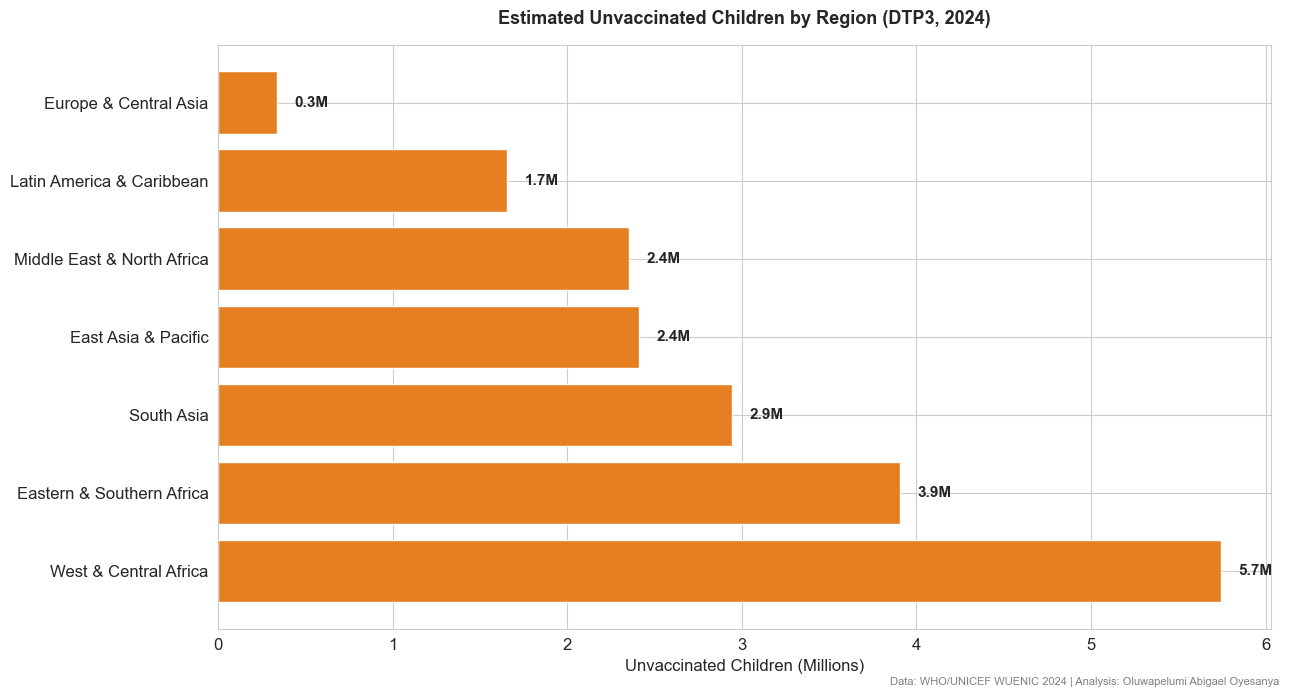

Chart 4 saved


In [19]:
# ============================================================
# CELL 9: CHART 4 — UNVACCINATED CHILDREN BY REGION (2024)
# ============================================================
# Coverage percentages can mask the true scale of the problem.
# This chart converts percentages into absolute numbers
# to show the real human impact behind the statistics.
# This is the kind of insight that separates a strong
# analyst from someone who just ran summary statistics.
# ============================================================

df_unvax = df_regional[
    (df_regional['vaccine'] == 'DTP3') &
    (df_regional['year']    == 2024) &
    (~df_regional['region'].isin(['Global', 'Non-programme']))
].copy()
df_unvax['region_label']   = df_unvax['region'].map(region_labels).fillna(df_unvax['region'])
df_unvax['unvax_millions'] = df_unvax['unvaccinated'] / 1_000_000
df_unvax = df_unvax.sort_values('unvax_millions', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(df_unvax['region_label'], df_unvax['unvax_millions'], color='#e67e22')
for bar, val in zip(bars, df_unvax['unvax_millions']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}M', va='center', fontsize=11, fontweight='bold')
ax.set_title('Estimated Unvaccinated Children by Region (DTP3, 2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Unvaccinated Children (Millions)')
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart4_unvaccinated_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved')

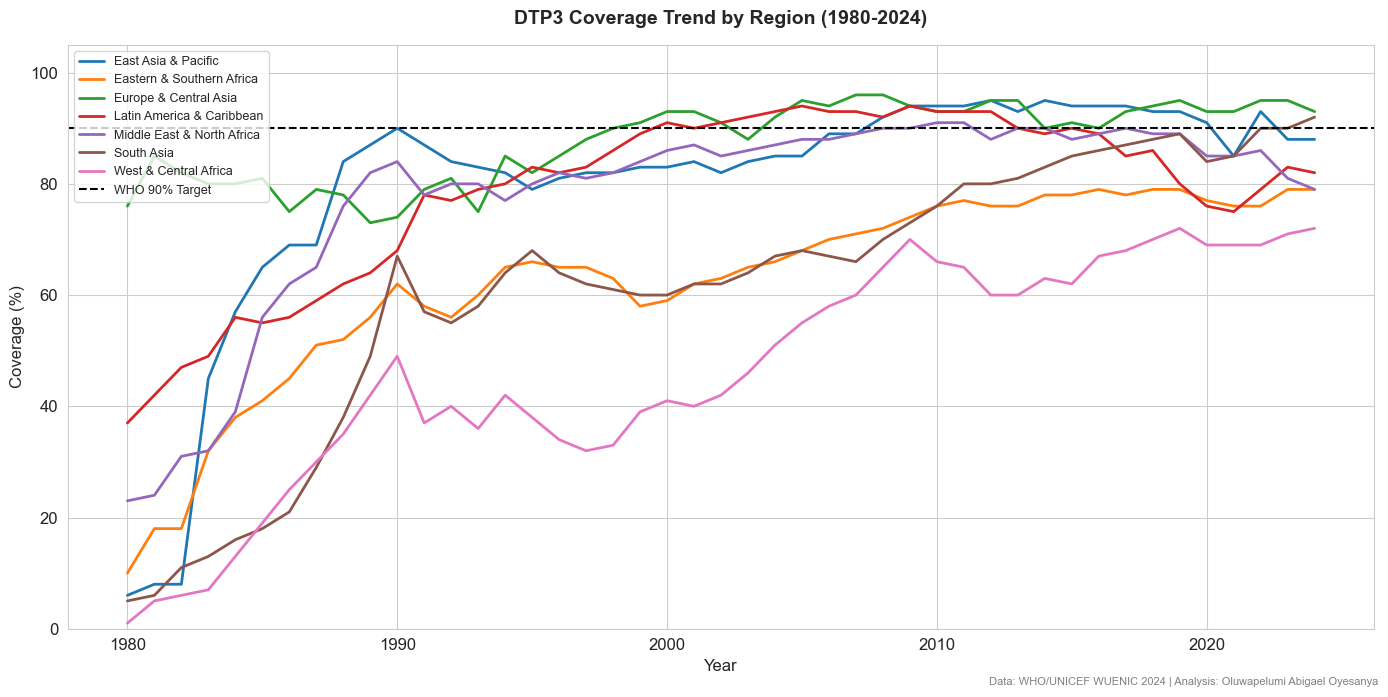

Chart 5 saved


In [20]:
# ============================================================
# CELL 10: CHART 5 — DTP3 REGIONAL TRENDS (1980-2024)
# ============================================================
# Shows 44 years of progress per region on one chart.
# Reveals which regions improved, which stagnated, and
# where the post-COVID dip is most visible after 2019.
# ============================================================

df_region_trend = df_regional[
    (df_regional['vaccine'] == 'DTP3') &
    (~df_regional['region'].isin(['Global', 'Non-programme']))
].copy()
df_region_trend['region_label'] = df_region_trend['region'].map(region_labels).fillna(df_region_trend['region'])
df_region_trend = df_region_trend.sort_values('year')

fig, ax = plt.subplots(figsize=(14, 7))
palette = sns.color_palette('tab10', n_colors=df_region_trend['region_label'].nunique())
for i, (region, grp) in enumerate(df_region_trend.groupby('region_label')):
    ax.plot(grp['year'], grp['coverage'], label=region, linewidth=2, color=palette[i])
ax.axhline(y=90, color='black', linestyle='--', linewidth=1.5, label='WHO 90% Target')
ax.set_title('DTP3 Coverage Trend by Region (1980-2024)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year'); ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 105)
ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart5_regional_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved')

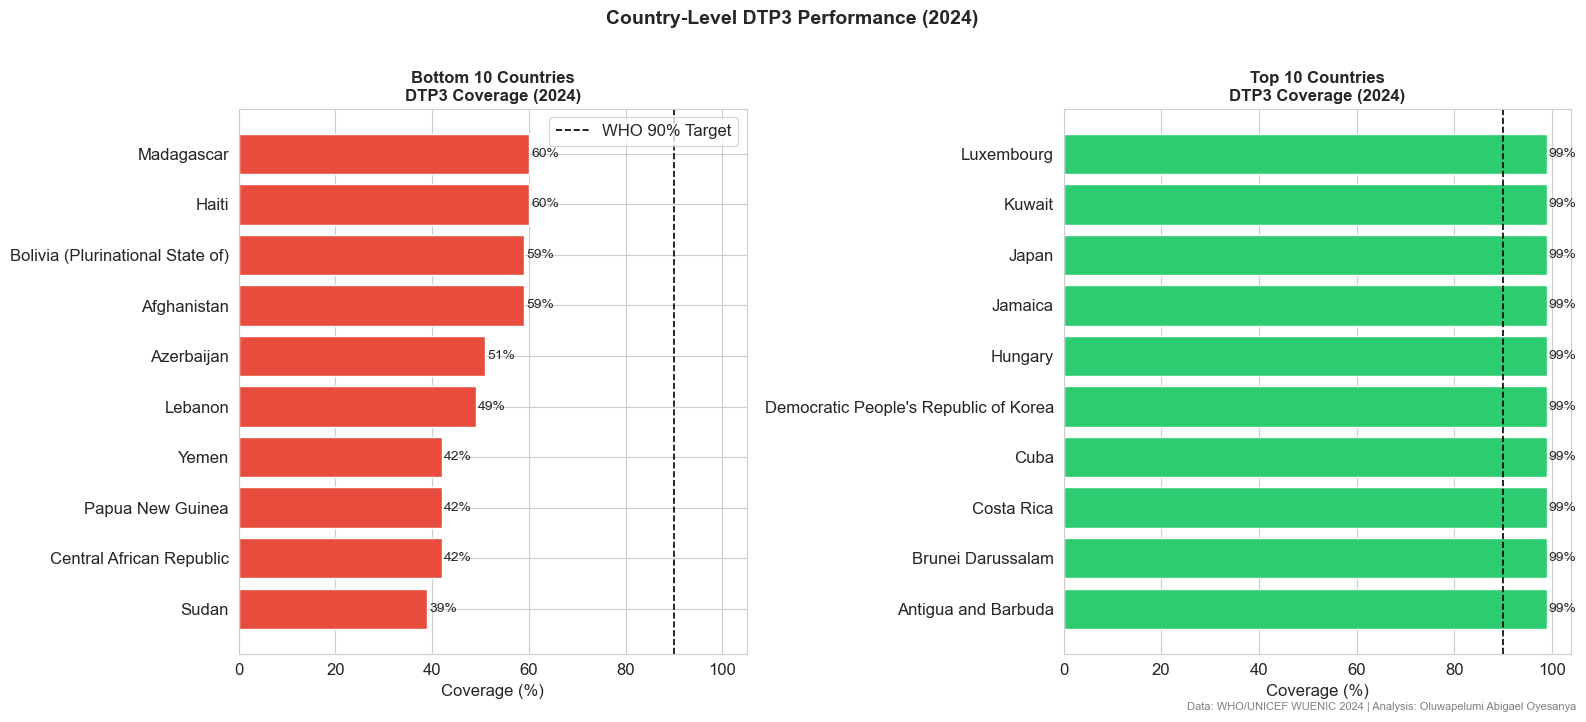

Chart 6 saved


In [21]:
# ============================================================
# CELL 11: CHART 6 — TOP 10 & BOTTOM 10 COUNTRIES (2024)
# ============================================================
# Drills down from regional to country level.
# The gap between best and worst countries is often 60+
# percentage points — reflecting deep inequities in health
# infrastructure, funding, geography, and conflict impact.
# ============================================================

df_country_2024 = full_dfs['DTP3'][full_dfs['DTP3']['year'] == 2024]
top10    = df_country_2024.nlargest(10, 'coverage').sort_values('coverage')
bottom10 = df_country_2024.nsmallest(10, 'coverage').sort_values('coverage')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh(bottom10['country'], bottom10['coverage'], color='#e74c3c')
ax1.axvline(x=90, color='black', linestyle='--', linewidth=1.2, label='WHO 90% Target')
for i, (_, row) in enumerate(bottom10.iterrows()):
    ax1.text(row['coverage'] + 0.5, i, f"{row['coverage']:.0f}%", va='center', fontsize=10)
ax1.set_title('Bottom 10 Countries\nDTP3 Coverage (2024)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Coverage (%)'); ax1.set_xlim(0, 105); ax1.legend()

ax2.barh(top10['country'], top10['coverage'], color='#2ecc71')
ax2.axvline(x=90, color='black', linestyle='--', linewidth=1.2)
for i, (_, row) in enumerate(top10.iterrows()):
    ax2.text(row['coverage'] + 0.3, i, f"{row['coverage']:.0f}%", va='center', fontsize=10)
ax2.set_title('Top 10 Countries\nDTP3 Coverage (2024)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Coverage (%)')

fig.suptitle('Country-Level DTP3 Performance (2024)', fontsize=14, fontweight='bold', y=1.01)
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart6_top_bottom_countries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved')

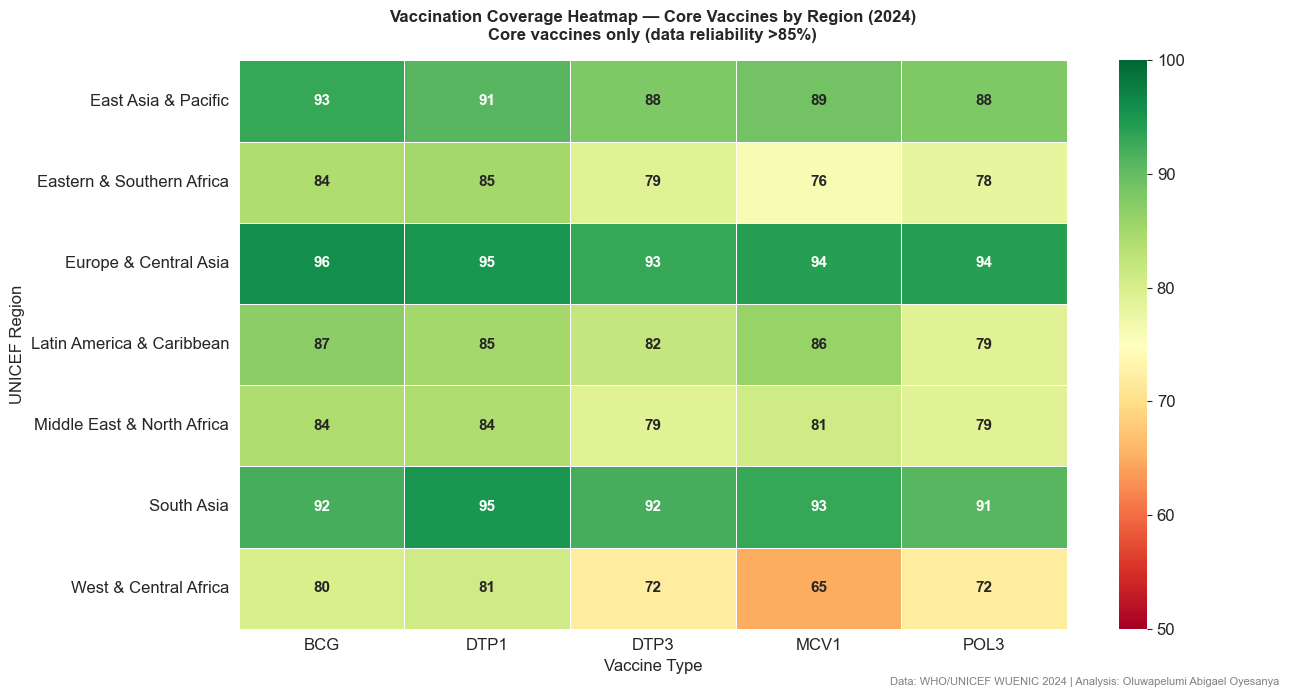

Chart 7 saved


In [22]:
# ============================================================
# CELL 12: CHART 7 — REGIONAL VACCINE HEATMAP (2024)
# ============================================================
# Shows all 5 core vaccines across all 7 regions in one view.
# Selected vaccines based on the project's data-quality criteria.
# programme reviews to quickly identify coverage gaps.
# ============================================================

heatmap_data = df_regional[
    (df_regional['year']    == 2024) &
    (df_regional['vaccine'].isin(selected_full)) &
    (~df_regional['region'].isin(['Global', 'Non-programme']))
].copy()
heatmap_data['region_label'] = heatmap_data['region'].map(region_labels).fillna(heatmap_data['region'])
heatmap_pivot = heatmap_data.pivot_table(
    index='region_label', columns='vaccine', values='coverage'
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=50, vmax=100, linewidths=0.5, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Vaccination Coverage Heatmap — Core Vaccines by Region (2024)\nCore vaccines only (data reliability >85%)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Vaccine Type'); ax.set_ylabel('UNICEF Region')
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart7_heatmap_region_vaccine.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved')

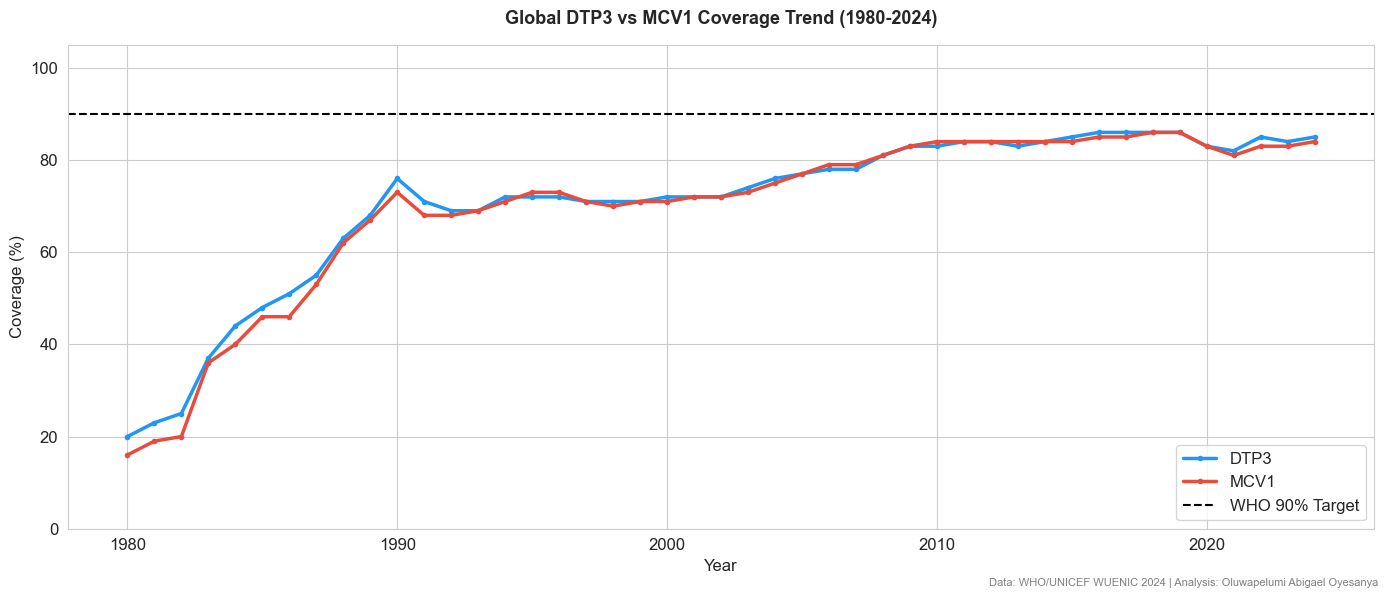

Chart 8 saved


In [23]:
# ============================================================
# CELL 13: CHART 8 — DTP3 VS MCV1 TREND COMPARISON
# ============================================================
# Comparing DTP3 and MCV1 over 44 years reveals whether
# countries vaccinating for DTP also vaccinate for measles.
# Persistent gaps between the two lines indicate systemic
# delivery failures in specific programmes or regions.
# ============================================================

df_compare = df_regional[
    (df_regional['vaccine'].isin(['DTP3', 'MCV1'])) &
    (df_regional['region']  == 'Global')
].sort_values('year')

fig, ax = plt.subplots(figsize=(14, 6))
colors_map = {'DTP3': '#2196F3', 'MCV1': '#e74c3c'}
for vaccine, grp in df_compare.groupby('vaccine'):
    ax.plot(grp['year'], grp['coverage'], label=vaccine,
            color=colors_map[vaccine], linewidth=2.5, marker='o', markersize=3)
ax.axhline(y=90, color='black', linestyle='--', linewidth=1.5, label='WHO 90% Target')
ax.set_title('Global DTP3 vs MCV1 Coverage Trend (1980-2024)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year'); ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 105); ax.legend()
fig.text(0.99, 0.01, 'Data: WHO/UNICEF WUENIC 2024 | Analysis: Oluwapelumi Abigael Oyesanya',
         ha='right', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig('charts/chart8_dtp3_vs_mcv1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 8 saved')

In [24]:
# ============================================================
# CELL 14: KEY INSIGHTS SUMMARY
# ============================================================
# Translates findings into plain health impact language.
# Numbers without interpretation are just numbers.
# This section answers: so what does this actually mean?
# ============================================================

print('=' * 60)
print('KEY INSIGHTS — GLOBAL IMMUNIZATION ANALYSIS (2024)')
print('=' * 60)

latest = df_global_dtp3[df_global_dtp3['year'] == 2024]['coverage'].values[0]
print(f'\n1. Global DTP3 coverage (2024) : {latest:.0f}%')
print(f'   {100 - latest:.0f}% of children did not receive the third DTP dose')

below = df_reg_2024[df_reg_2024['coverage'] < 90]
print(f'\n2. {len(below)} of 7 UNICEF regions are still below the WHO 90% target:')
for _, row in below.sort_values('coverage').iterrows():
    print(f'   {row["region_label"]}: {row["coverage"]:.0f}% ({90 - row["coverage"]:.0f}% gap to close)')

global_unvax = df_regional[
    (df_regional['vaccine'] == 'DTP3') &
    (df_regional['year']    == 2024) &
    (df_regional['region']  == 'Global')
]['unvaccinated'].values[0]
print(f'\n3. Unvaccinated children globally (DTP3, 2024): {global_unvax:,.0f}')

worst_region = df_unvax.iloc[0]
print(f'\n4. Highest burden region : {worst_region["region_label"]}')
print(f'   {worst_region["unvax_millions"]:.1f} million unvaccinated children')

worst_country = df_country_2024.nsmallest(1, 'coverage').iloc[0]
print(f'\n5. Lowest performing country : {worst_country["country"]} at {worst_country["coverage"]:.0f}% DTP3 coverage')

print('\n' + '=' * 60)
print('Project 1 Complete — 8 charts generated')
print('Next: Power BI dashboard using cleaned_wuenic2024_final.xlsx')
print('=' * 60)

KEY INSIGHTS — GLOBAL IMMUNIZATION ANALYSIS (2024)

1. Global DTP3 coverage (2024) : 85%
   15% of children did not receive the third DTP dose

2. 5 of 7 UNICEF regions are still below the WHO 90% target:
   West & Central Africa: 72% (18% gap to close)
   Eastern & Southern Africa: 79% (11% gap to close)
   Middle East & North Africa: 79% (11% gap to close)
   Latin America & Caribbean: 82% (8% gap to close)
   East Asia & Pacific: 88% (2% gap to close)

3. Unvaccinated children globally (DTP3, 2024): 19,932,000

4. Highest burden region : West & Central Africa
   5.7 million unvaccinated children

5. Lowest performing country : Sudan at 39% DTP3 coverage

Project 1 Complete — 8 charts generated
Next: Power BI dashboard using cleaned_wuenic2024_final.xlsx
